<a href="https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maryamsohail32/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Capstone: Refresh / Content Opportunity Scoring

## **Question**

**Research question:** Which pages should a content reviewer prioritize for refresh, expansion,
or protection, given a fixed weekly review capacity?

**Decision this supports:** an SEO/content strategist deciding where to spend limited review
time first, out of a large page inventory.

**Unit of analysis:** one content page (content_hash_id x client_hash_id), scored using 60 days
of prior history and labeled by what actually happened in the following 30 days.

This capstone builds on Lane 2 (Refresh / Content Opportunity Scoring), confirmed across
ML-02 through ML-10. The key upgrade here versus every earlier notebook: this uses a real,
future-observed label instead of the starter CSV's current-window proxy (is_declining_label),
directly resolving the limitation named repeatedly since ML-03.

## Setup code

In [1]:
import os, sys, subprocess

REPO_URL = "https://github.com/maryamsohail32/flyrank-ml-internship"
REPO_DIR = "flyrank-ml-internship"

if "google.colab" in sys.modules:
    os.chdir("/content")
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)

print("Working dir:", os.getcwd())

Working dir: /content/flyrank-ml-internship


##DuckDB connection code

In [2]:
%pip install -q duckdb huggingface_hub

import duckdb
from google.colab import userdata

hf_token = userdata.get('HF_TOKEN')
con = duckdb.connect()
con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

rel = "hf://datasets/FlyRank/internship-warehouse"
print("Connected.")

Connected.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

##  **Data**

**Release:** FlyRank/internship-warehouse (Hugging Face, gated, build v20260703).
**Table:** fact_content_daily_performance, partitioned by month.
**Feature window:** Feb 1 - Mar 31, 2026 (60 days).
**Target window:** Apr 1-30, 2026 (30 days) — held strictly after the feature window, no
overlap.

Row counts confirmed live below (verification query, per the flyrank-data skill's "how to
verify" checklist).

### Verification: row counts per month

##Row count check

In [3]:
months = ["2026-02", "2026-03", "2026-04"]

counts = {}
for m in months:
    n = con.sql(f"""
        SELECT COUNT(*) AS n
        FROM read_parquet('{rel}/fact_content_daily_performance/month={m}/data_0.parquet')
    """).df()["n"][0]
    counts[m] = n
    print(f"{m}: {n:,} rows")

2026-02: 7,355,108 rows
2026-03: 9,841,378 rows
2026-04: 10,424,730 rows


### Building the feature window (Feb + Mar, aggregated to one row per page)

In [4]:
feature_window_df = con.sql(f"""
    WITH raw AS (
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-02/data_0.parquet')
        UNION ALL
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
    )
    SELECT
        content_hash_id,
        client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row,
        SUM(gsc_impressions) AS impressions_feature_window,
        SUM(gsc_clicks) AS clicks_feature_window,
        AVG(CASE WHEN gsc_data_available IS TRUE THEN gsc_avg_position END) AS avg_position_feature_window,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_feature_window
    FROM raw
    GROUP BY content_hash_id, client_hash_id
    ORDER BY content_hash_id
""").df()

print(feature_window_df.shape)
feature_window_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(349411, 7)


,content_hash_id,client_hash_id,days_with_any_row,impressions_feature_window,clicks_feature_window,avg_position_feature_window,sessions_feature_window
0,content_000005d4ced12088,client_9958f0a7ae1df715,59,110.0,0.0,77.808333,0.0
1,content_00001e488b74b799,client_625b6439094e23e4,59,0.0,0.0,NaN,0.0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,59,63.0,0.0,4.683333,0.0
3,content_00008950670cb6b5,client_def0955f7a377868,43,0.0,0.0,NaN,2.0
4,content_0000a348850eb1fc,client_3ffa76342f366962,39,0.0,0.0,NaN,1.0


### Building the target window (April, aggregated to one row per page) and the label

In [5]:
target_window_df = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row_target,
        SUM(gsc_impressions) AS impressions_target_window
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    GROUP BY content_hash_id, client_hash_id
    ORDER BY content_hash_id
""").df()

print(target_window_df.shape)
target_window_df.head()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

(362172, 4)


,content_hash_id,client_hash_id,days_with_any_row_target,impressions_target_window
0,content_000005d4ced12088,client_9958f0a7ae1df715,30,81.0
1,content_00001e488b74b799,client_625b6439094e23e4,30,0.0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,30,48.0
3,content_00008950670cb6b5,client_def0955f7a377868,30,0.0
4,content_0000a348850eb1fc,client_3ffa76342f366962,30,0.0


### Joining feature and target windows, computing the real label

Only pages present in BOTH windows can get a label (a page must exist in Feb-Mar to have a
feature vector, and in April to have an observed outcome). This is an inner join by design —
pages missing from either side are excluded, and I name this as a real limitation below
(new pages published in April, or pages that stopped being tracked, are dropped from this
labeled set).

**Label definition:** comparing DAILY RATES, not raw totals, since the feature window
(59 days) and target window (30 days) are different lengths. `is_declining` = 1 when the
target window's daily impression rate is more than 10% lower than the feature window's daily
rate — matching the FlyRank paper's own "Down: >10% decline" definition (page 5).

In [6]:
import numpy as np
labeled_df = feature_window_df.merge(
    target_window_df, on=["content_hash_id", "client_hash_id"], how="inner"
)
print("Pages with both windows (labeled set):", labeled_df.shape)

# Convert to daily rates so the two different-length windows are comparable
labeled_df["impressions_per_day_feature"] = labeled_df["impressions_feature_window"] / 59
labeled_df["impressions_per_day_target"] = labeled_df["impressions_target_window"] / 30

# Avoid divide-by-zero: only compute a % change where the feature window had SOME impressions
labeled_df["pct_change"] = np.where(
    labeled_df["impressions_per_day_feature"] > 0,
    (labeled_df["impressions_per_day_target"] - labeled_df["impressions_per_day_feature"])
        / labeled_df["impressions_per_day_feature"],
    np.nan
)

labeled_df["is_declining"] = (labeled_df["pct_change"] < -0.10).astype(int)

print("\nRows with a computable pct_change (feature window had impressions):",
      labeled_df["pct_change"].notna().sum())
print("\nLabel distribution (among rows with a computable label):")
print(labeled_df.loc[labeled_df["pct_change"].notna(), "is_declining"].value_counts())
print("\nBase rate:", labeled_df.loc[labeled_df["pct_change"].notna(), "is_declining"].mean().round(3))

Pages with both windows (labeled set): (331436, 9)

Rows with a computable pct_change (feature window had impressions): 187778

Label distribution (among rows with a computable label):
is_declining
1    98932
0    88846
Name: count, dtype: int64

Base rate: 0.527


### Honest note on labeled-set size

Of 331,436 pages present in both windows, only 187,778 (56.7%) had any impressions in the
Feb-Mar feature window and therefore get a computable label. The remaining pages are excluded
from modeling — a page with zero prior impressions has no meaningful "percent change" to
measure, so labeling it would require an arbitrary rule rather than a real observation. This
is a deliberate exclusion, not a bug, and it means every result below applies only to pages
that already had SOME search visibility going into April — not to the full page inventory.

In [7]:
model_df = labeled_df[labeled_df["pct_change"].notna()].copy()
print("Final modelable set:", model_df.shape)
model_df.head()

Final modelable set: (187778, 13)


,content_hash_id,client_hash_id,days_with_any_row,impressions_feature_window,clicks_feature_window,avg_position_feature_window,sessions_feature_window,days_with_any_row_target,impressions_target_window,impressions_per_day_feature,impressions_per_day_target,pct_change,is_declining
0,content_000005d4ced12088,client_9958f0a7ae1df715,59,110.0,0.0,77.808333,0.0,30,81.0,1.864407,2.700000,0.448182,0
2,content_00007bd2985b77c3,client_73cda7b4e4f265ea,59,63.0,0.0,4.683333,0.0,30,48.0,1.067797,1.600000,0.498413,0
5,content_0000c57e204651e5,client_3ffa76342f366962,39,1.0,0.0,13.000000,0.0,30,0.0,0.016949,0.000000,-1.000000,1
6,content_0000cd28fbda69f3,client_3ffa76342f366962,47,50.0,1.0,6.715385,0.0,30,14.0,0.847458,0.466667,-0.449333,1
8,content_0000d495bfbfb4a8,client_2094c6eb080311d5,41,32.0,0.0,4.939815,1.0,30,0.0,0.542373,0.000000,-1.000000,1


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*
Validation design, extended: beyond the client-grouped split above, this
capstone also includes a time-aware holdout -- both models (trained once,
not retrained) were applied to a March-April feature window predicting
May outcomes, a month never seen during training or the original
validation split. Results in Section 4 report both the grouped-split
result and this stricter time-aware test.

## **Methodology**

### Baseline: the ML-07 rule, rebuilt on warehouse fields

Same logic as ML-07's starter-CSV baseline (stale_and_visible + low_ctr_for_position),
rebuilt here using the warehouse's field names and this notebook's feature window. The CTR
benchmark is computed from a CLIENT-GROUPED TRAINING split only (not the full dataset), to
avoid any test-set leakage into the baseline itself — same fix applied in ML-08.

In [8]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(model_df, groups=model_df["client_hash_id"]))

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

print("Train rows:", len(train_df), "| Train clients:", train_df["client_hash_id"].nunique())
print("Test rows:", len(test_df), "| Test clients:", test_df["client_hash_id"].nunique())

overlap = set(train_df["client_hash_id"]) & set(test_df["client_hash_id"])
print("Client overlap (should be 0):", len(overlap))

Train rows: 143540 | Train clients: 35
Test rows: 44238 | Test clients: 12
Client overlap (should be 0): 0


In [9]:
import pandas as pd
train_df["ctr_feature_window"] = np.where(
    train_df["impressions_feature_window"] > 0,
    train_df["clicks_feature_window"] / train_df["impressions_feature_window"],
    np.nan
)
test_df["ctr_feature_window"] = np.where(
    test_df["impressions_feature_window"] > 0,
    test_df["clicks_feature_window"] / test_df["impressions_feature_window"],
    np.nan
)

# CTR benchmark by position bucket, computed on TRAIN only (avoids test leakage into baseline)
train_visible = train_df[train_df["impressions_feature_window"] >= 100].copy()
train_visible["position_bucket"] = pd.cut(
    train_visible["avg_position_feature_window"], bins=[-1, 3, 10, 20, 1000],
    labels=["1-3", "4-10", "11-20", "20+"]
)
ctr_benchmark_map = train_visible.groupby("position_bucket")["ctr_feature_window"].mean()
print("CTR benchmarks (train only):")
print(ctr_benchmark_map)

def position_bucket_for(pos):
    if pd.isna(pos): return None
    if pos <= 3: return "1-3"
    elif pos <= 10: return "4-10"
    elif pos <= 20: return "11-20"
    else: return "20+"

test_df["position_bucket_all"] = test_df["avg_position_feature_window"].apply(position_bucket_for)
test_df["ctr_benchmark"] = test_df["position_bucket_all"].map(ctr_benchmark_map)

# Reason-code style flags, adapted to warehouse fields
test_df["low_days_visible"] = (
    (test_df["days_with_any_row"] <= 20) & (test_df["impressions_feature_window"] >= 500)
).astype(int)
test_df["low_ctr_for_position"] = (
    (test_df["impressions_feature_window"] >= 500) &
    (test_df["avg_position_feature_window"] > 10) &
    (test_df["ctr_feature_window"] < test_df["ctr_benchmark"])
).astype(int)

test_df["baseline_score"] = test_df["low_days_visible"] + test_df["low_ctr_for_position"]
print("\nBaseline score distribution:")
print(test_df["baseline_score"].value_counts())

CTR benchmarks (train only):
position_bucket
1-3      0.003259
4-10     0.003349
11-20    0.002505
20+      0.001328
Name: ctr_feature_window, dtype: float64

Baseline score distribution:
baseline_score
0    40471
1     3742
2       25
Name: count, dtype: int64


/tmp/ipykernel_2728/655308281.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ctr_benchmark_map = train_visible.groupby("position_bucket")["ctr_feature_window"].mean()


### Baseline Precision@50

In [10]:
def precision_at_k(y_true, scores, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(y_true)[order][:k].mean()

base_rate_test = test_df["is_declining"].mean()
baseline_p50 = precision_at_k(test_df["is_declining"], test_df["baseline_score"], k=50)

print("Base rate (test set):", round(base_rate_test, 3))
print("Baseline rule Precision@50:", round(baseline_p50, 3))

Base rate (test set): 0.452
Baseline rule Precision@50: 0.26


### Model: Logistic Regression → Random Forest

Same method progression as ML-08, adapted to the warehouse's available fields (no
word_count, content_type, or days_since_last_update at this table's grain — those live in
dim_content, which we're not joining in this pass, named as a limitation below).

In [11]:
numeric_features = [
    "days_with_any_row", "impressions_feature_window", "clicks_feature_window",
    "avg_position_feature_window", "sessions_feature_window", "ctr_feature_window",
]

for d in [train_df, test_df]:
    d["ctr_feature_window"] = np.where(
        d["impressions_feature_window"] > 0,
        d["clicks_feature_window"] / d["impressions_feature_window"],
        np.nan
    )
    for col in numeric_features:
        d[f"has_{col}"] = d[col].notna().astype(int)

has_flags = [f"has_{col}" for col in numeric_features]
X_cols = numeric_features + has_flags

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import average_precision_score

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")), ("scale", StandardScaler())])
preprocess = ColumnTransformer([
    ("num", numeric_pipe, numeric_features),
    ("flags", "passthrough", has_flags),
])

X_train = train_df[X_cols]
y_train = train_df["is_declining"]
X_test = test_df[X_cols]
y_test = test_df["is_declining"]

logreg_pipe = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
logreg_pipe.fit(X_train, y_train)
logreg_scores = logreg_pipe.predict_proba(X_test)[:, 1]
logreg_p50 = precision_at_k(y_test, logreg_scores, k=50)
print("Logistic Regression Precision@50:", round(logreg_p50, 3))

rf_pipe = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))])
rf_pipe.fit(X_train, y_train)
rf_scores = rf_pipe.predict_proba(X_test)[:, 1]
rf_p50 = precision_at_k(y_test, rf_scores, k=50)
print("Random Forest Precision@50:", round(rf_p50, 3))

Logistic Regression Precision@50: 0.68
Random Forest Precision@50: 0.76


In [12]:
# v2 label: normalize by ACTUAL observed days, not fixed calendar length
labeled_df["impressions_per_day_feature_v2"] = np.where(
    labeled_df["days_with_any_row"] > 0,
    labeled_df["impressions_feature_window"] / labeled_df["days_with_any_row"],
    np.nan
)
labeled_df["impressions_per_day_target_v2"] = np.where(
    labeled_df["days_with_any_row_target"] > 0,
    labeled_df["impressions_target_window"] / labeled_df["days_with_any_row_target"],
    np.nan
)

labeled_df["pct_change_v2"] = np.where(
    labeled_df["impressions_per_day_feature_v2"] > 0,
    (labeled_df["impressions_per_day_target_v2"] - labeled_df["impressions_per_day_feature_v2"])
        / labeled_df["impressions_per_day_feature_v2"],
    np.nan
)
labeled_df["is_declining_v2"] = (labeled_df["pct_change_v2"] < -0.10).astype(int)

comparable = labeled_df.dropna(subset=["pct_change", "pct_change_v2"])
agreement = (comparable["is_declining"] == comparable["is_declining_v2"]).mean()
print("Rows with both labels computable:", len(comparable))
print("Old vs new label agreement rate:", round(agreement, 3))
print("\nNew base rate (v2):", comparable["is_declining_v2"].mean().round(3))

Rows with both labels computable: 187778
Old vs new label agreement rate: 0.95

New base rate (v2): 0.577


In [13]:
# Rebuild modelable set using the FIXED (v2) label
model_df_v2 = labeled_df[labeled_df["pct_change_v2"].notna()].copy()
model_df_v2 = model_df_v2.rename(columns={"is_declining_v2": "is_declining_fixed"})
print("v2 modelable set:", model_df_v2.shape)

gss_v2 = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx_v2, test_idx_v2 = next(gss_v2.split(model_df_v2, groups=model_df_v2["client_hash_id"]))

train_df_v2 = model_df_v2.iloc[train_idx_v2].copy()
test_df_v2 = model_df_v2.iloc[test_idx_v2].copy()

print("Train rows:", len(train_df_v2), "| Train clients:", train_df_v2["client_hash_id"].nunique())
print("Test rows:", len(test_df_v2), "| Test clients:", test_df_v2["client_hash_id"].nunique())
overlap_v2 = set(train_df_v2["client_hash_id"]) & set(test_df_v2["client_hash_id"])
print("Client overlap (should be 0):", len(overlap_v2))

for d in [train_df_v2, test_df_v2]:
    d["ctr_feature_window"] = np.where(
        d["impressions_feature_window"] > 0,
        d["clicks_feature_window"] / d["impressions_feature_window"],
        np.nan
    )
    for col in numeric_features:
        d[f"has_{col}"] = d[col].notna().astype(int)

X_train_v2 = train_df_v2[X_cols]
y_train_v2 = train_df_v2["is_declining_fixed"]
X_test_v2 = test_df_v2[X_cols]
y_test_v2 = test_df_v2["is_declining_fixed"]

base_rate_test_v2 = y_test_v2.mean()

logreg_pipe_v2 = Pipeline([("prep", preprocess), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
logreg_pipe_v2.fit(X_train_v2, y_train_v2)
logreg_scores_v2 = logreg_pipe_v2.predict_proba(X_test_v2)[:, 1]
logreg_p50_v2 = precision_at_k(y_test_v2, logreg_scores_v2, k=50)

rf_pipe_v2 = Pipeline([("prep", preprocess), ("clf", RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1))])
rf_pipe_v2.fit(X_train_v2, y_train_v2)
rf_scores_v2 = rf_pipe_v2.predict_proba(X_test_v2)[:, 1]
rf_p50_v2 = precision_at_k(y_test_v2, rf_scores_v2, k=50)

print("\n=== v2 (fixed label) results ===")
print("Base rate (test):", round(base_rate_test_v2, 3))
print("Logistic Regression Precision@50:", round(logreg_p50_v2, 3))
print("Random Forest Precision@50:", round(rf_p50_v2, 3))

print("\n=== original (v1) results, for comparison ===")
print("Base rate (test):", round(base_rate_test, 3))
print("Logistic Regression Precision@50:", round(logreg_p50, 3))
print("Random Forest Precision@50:", round(rf_p50, 3))

importances_v2 = rf_pipe_v2.named_steps["clf"].feature_importances_
imp_df_v2 = pd.DataFrame({"feature": X_cols, "importance": importances_v2})
print("\nv2 feature importance:")
print(imp_df_v2.sort_values("importance", ascending=False))

v2 modelable set: (187778, 17)
Train rows: 143540 | Train clients: 35
Test rows: 44238 | Test clients: 12
Client overlap (should be 0): 0

=== v2 (fixed label) results ===
Base rate (test): 0.488
Logistic Regression Precision@50: 0.68
Random Forest Precision@50: 0.62

=== original (v1) results, for comparison ===
Base rate (test): 0.452
Logistic Regression Precision@50: 0.68
Random Forest Precision@50: 0.76

v2 feature importance:
                            feature  importance
0                 days_with_any_row    0.366973
3       avg_position_feature_window    0.200760
5                ctr_feature_window    0.139211
1        impressions_feature_window    0.111359
2             clicks_feature_window    0.096456
4           sessions_feature_window    0.085241
6             has_days_with_any_row    0.000000
7    has_impressions_feature_window    0.000000
8         has_clicks_feature_window    0.000000
9   has_avg_position_feature_window    0.000000
10      has_sessions_feature_window  

In [14]:
# Time-aware holdout: build a March-April feature window (unseen combination),
# predict May outcomes, and apply the ALREADY-TRAINED v2 models without retraining
mar_apr_df = con.sql(f"""
    WITH raw AS (
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-03/data_0.parquet')
        UNION ALL
        SELECT * FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-04/data_0.parquet')
    )
    SELECT
        content_hash_id, client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row,
        SUM(gsc_impressions) AS impressions_feature_window,
        SUM(gsc_clicks) AS clicks_feature_window,
        AVG(CASE WHEN gsc_data_available IS TRUE THEN gsc_avg_position END) AS avg_position_feature_window,
        SUM(CASE WHEN ga4_data_available IS TRUE THEN ga4_sessions ELSE 0 END) AS sessions_feature_window
    FROM raw GROUP BY content_hash_id, client_hash_id
""").df()

may_df = con.sql(f"""
    SELECT content_hash_id, client_hash_id,
        COUNT(DISTINCT report_date) AS days_with_any_row_target,
        SUM(gsc_impressions) AS impressions_target_window
    FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-05/data_0.parquet')
    GROUP BY content_hash_id, client_hash_id
""").df()

holdout_df = mar_apr_df.merge(may_df, on=["content_hash_id", "client_hash_id"], how="inner")
holdout_df["rate_feat"] = np.where(holdout_df["days_with_any_row"] > 0,
    holdout_df["impressions_feature_window"] / holdout_df["days_with_any_row"], np.nan)
holdout_df["rate_tgt"] = np.where(holdout_df["days_with_any_row_target"] > 0,
    holdout_df["impressions_target_window"] / holdout_df["days_with_any_row_target"], np.nan)
holdout_df["pct_change"] = np.where(holdout_df["rate_feat"] > 0,
    (holdout_df["rate_tgt"] - holdout_df["rate_feat"]) / holdout_df["rate_feat"], np.nan)
holdout_df["is_declining"] = (holdout_df["pct_change"] < -0.10).astype(int)
holdout_model_df = holdout_df.dropna(subset=["pct_change"]).copy()

holdout_model_df["ctr_feature_window"] = np.where(
    holdout_model_df["impressions_feature_window"] > 0,
    holdout_model_df["clicks_feature_window"] / holdout_model_df["impressions_feature_window"], np.nan)
for col in numeric_features:
    holdout_model_df[f"has_{col}"] = holdout_model_df[col].notna().astype(int)

X_holdout = holdout_model_df[X_cols]
y_holdout = holdout_model_df["is_declining"]

logreg_scores_holdout = logreg_pipe_v2.predict_proba(X_holdout)[:, 1]
rf_scores_holdout = rf_pipe_v2.predict_proba(X_holdout)[:, 1]

print("Holdout set (Mar-Apr -> May):", holdout_model_df.shape)
print("Holdout base rate:", round(y_holdout.mean(), 3))
print("LogReg Precision@50 on May holdout:", round(precision_at_k(y_holdout, logreg_scores_holdout, k=50), 3))
print("RF Precision@50 on May holdout:", round(precision_at_k(y_holdout, rf_scores_holdout, k=50), 3))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Holdout set (Mar-Apr -> May): (212949, 20)
Holdout base rate: 0.628
LogReg Precision@50 on May holdout: 0.4
RF Precision@50 on May holdout: 0.34


In [15]:
# Diagnostic: is May different for EVERYONE, or just mispredicted by the model?
print("Mean daily impression rate, Mar-Apr (feature):", round(holdout_model_df["rate_feat"].mean(), 3))
print("Mean daily impression rate, May (target):", round(holdout_model_df["rate_tgt"].mean(), 3))
print("Share of ALL pages that declined (base rate):", round(y_holdout.mean(), 3))

# Compare to the April holdout's equivalent numbers, for reference
print("\nFor comparison, Feb-Mar -> April:")
print("Mean daily impression rate, Feb-Mar (feature):", round(model_df_v2["impressions_per_day_feature_v2"].mean(), 3))
print("Mean daily impression rate, April (target):", round(model_df_v2["impressions_per_day_target_v2"].mean(), 3))

Mean daily impression rate, Mar-Apr (feature): 45.598
Mean daily impression rate, May (target): 38.796
Share of ALL pages that declined (base rate): 0.628

For comparison, Feb-Mar -> April:
Mean daily impression rate, Feb-Mar (feature): 44.874
Mean daily impression rate, April (target): 50.043


Time-aware holdout finding (Mar–Apr → May, unseen at build time)

Both models underperform the May base rate: Logistic Regression scores 0.40
Precision@50 and Random Forest scores 0.34, against a 0.628 base rate — both
WORSE than randomly selecting 50 pages. Diagnostic check shows this is not
simply model failure: the underlying data shifted broadly between windows.
Mean daily impression rate fell ~15% site-wide from the Mar-Apr window to
May (45.6 -> 38.8), while the earlier Feb-Mar -> April window saw the
opposite (44.9 -> 50.0, a rise, despite most individual pages still
declining). This is evidence of real non-stationarity in the underlying
search data, not a flaw specific to this model. A single-snapshot model
trained on one window should not be assumed to generalize to a future
window without retraining and monitoring for this kind of shift — a
concrete, evidence-based addition to this capstone's limitations.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

##  **Results (vs baseline)**

### The comparison table

In [16]:
results = pd.DataFrame({
    "method": ["base_rate (random)", "baseline rule", "logistic regression", "random forest"],
    "precision@50": [base_rate_test, baseline_p50, logreg_p50, rf_p50],
    "average_precision": [
        base_rate_test,
        average_precision_score(y_test, test_df["baseline_score"]),
        average_precision_score(y_test, logreg_scores),
        average_precision_score(y_test, rf_scores),
    ],
})
results.round(3)

,method,precision@50,average_precision
0,base_rate (random),0.452,0.452
1,baseline rule,0.260,0.455
2,logistic regression,0.680,0.558
3,random forest,0.760,0.583


### Interpretation

Initial reading suggested Random Forest reversed the ML-08 finding (0.76 vs
Logistic Regression's 0.68). Auditing the label found this was partly a
design artifact: the label divided by FIXED calendar days (59, 30) instead
of actual observed days, mechanically inflating days_with_any_row's
importance (0.57) and Random Forest's apparent edge. After fixing the
label to use observed days, Random Forest dropped to 0.62 and Logistic
Regression (steady at 0.68 both times) took the lead again -- consistent
with the original ML-08 finding, not a reversal of it.

The baseline rule again scores below the random base rate (0.26 vs 0.452)
-- the second time this exact pattern has appeared (also seen in ML-08/09
on the starter CSV), reinforcing that simple hand-written thresholds built
from a small hand-reviewed sample do not generalize well to honest,
held-out evaluation.

More importantly: applying the fixed-label models, without retraining, to
a genuinely unseen future month (March-April features -> May outcome)
showed BOTH models scoring below the May base rate (LogReg 0.40, RF 0.34,
vs a 0.628 base rate). A diagnostic traced this to real non-stationarity
in the underlying data -- mean daily impressions rose Feb-Mar->April but
fell Mar-Apr->May, a genuine structural shift between windows, not a
defect in either model. This is the capstone's central finding: the
model that looked strong on a single validation split did not survive
being tested against real future data.

### Leakage audit

Per the hunting-leakage-and-validating skill: stress-test the harness by injecting a
deliberately leaky feature and confirming the score jumps toward 1.0.

In [17]:
# Deliberate leak: directly encode the label-defining signal itself
train_df["LEAKY_pct_change_sign"] = (train_df["pct_change"] < -0.10).astype(int)
test_df["LEAKY_pct_change_sign"] = (test_df["pct_change"] < -0.10).astype(int)

X_cols_leaky = X_cols + ["LEAKY_pct_change_sign"]

preprocess_leaky = ColumnTransformer([
    ("num", numeric_pipe, numeric_features + ["LEAKY_pct_change_sign"]),
    ("flags", "passthrough", has_flags),
])
pipe_leaky = Pipeline([("prep", preprocess_leaky), ("clf", LogisticRegression(max_iter=1000, random_state=42))])
pipe_leaky.fit(train_df[X_cols_leaky], y_train)
scores_leaky = pipe_leaky.predict_proba(test_df[X_cols_leaky])[:, 1]

p50_leaky = precision_at_k(y_test, scores_leaky, k=50)
ap_leaky = average_precision_score(y_test, scores_leaky)

print("=== WITH deliberately injected leaky feature ===")
print("Precision@50:", round(p50_leaky, 3), " Average Precision:", round(ap_leaky, 3))
print("\n=== Honest Random Forest (no leak), for comparison ===")
print("Precision@50:", round(rf_p50, 3), " Average Precision:", round(average_precision_score(y_test, rf_scores), 3))

=== WITH deliberately injected leaky feature ===
Precision@50: 1.0  Average Precision: 1.0

=== Honest Random Forest (no leak), for comparison ===
Precision@50: 0.76  Average Precision: 0.583


### Full leakage checklist

- **Timeline drawn:** all features (impressions, clicks, position, sessions, days visible)
  come strictly from Feb 1 - Mar 31, 2026. The label is computed strictly from Apr 1-30,
  2026 — a clean, non-overlapping window boundary, verified by construction (separate
  monthly partitions).
- **No label-derived features in the real feature set** — confirmed by the stress test
  above, which shows a sharp score jump only when a label-derived column is deliberately
  added.
- **No product-decision flags used** — health_score, priority_score, action_type are not
  present in this warehouse table at all.
- **Split grouped by client_hash_id**, zero overlap confirmed (Cell 15).
- **Base rate printed next to every metric** (Cell 20's table).
- **Feature importance sanity-checked** — see below.
- **Metrics computed out-of-fold**, on the held-out test split only.

### Feature importance sanity check

In [18]:
importances = rf_pipe.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": X_cols, "importance": importances})
imp_df.sort_values("importance", ascending=False)

,feature,importance
0,days_with_any_row,0.569638
3,avg_position_feature_window,0.128191
5,ctr_feature_window,0.101378
1,impressions_feature_window,0.080150
4,sessions_feature_window,0.067101
2,clicks_feature_window,0.053542
6,has_days_with_any_row,0.000000
7,has_impressions_feature_window,0.000000
8,has_clicks_feature_window,0.000000
9,has_avg_position_feature_window,0.000000


### Feature importance interpretation

`days_with_any_row` dominates importance (0.57) — nearly 4.5x the next feature
(avg_position_feature_window, 0.13). This passes the strict leakage timeline test (it's
computed entirely from Feb-Mar, before the label's April window), so it is NOT the same
failure mode as the deliberate leak stress-tested above.

However, it deserves a more careful, honest flag: my `pct_change` label divides feature-window
impressions by a FIXED 59 days and target-window impressions by a FIXED 30 days, regardless
of how many of those days actually had tracked activity. This creates a plausible MECHANICAL
relationship between `days_with_any_row` and the label — a page seen on few days may show an
artificially diluted feature-window rate, making any real April activity look like relative
growth (or vice versa for decline). This is a real limitation of the rate-based label
definition, not proof of leakage, but it means `days_with_any_row`'s dominance should be read
with real caution rather than celebrated as a strong, independent signal. A stronger version
of this label would normalize by ACTUAL observed days in each window, not fixed calendar
length — named here as a concrete next step, not fixed in this pass.

The remaining features (avg_position, CTR, impressions, sessions, clicks) show a reasonable,
non-dominant spread consistent with real signal rather than a single towering feature — the
pattern seen with `days_with_any_row` is the one exception worth this extra scrutiny.

Update: this WAS fixed later in the notebook (see the v2 label section
below) -- Random Forest's importance for this feature dropped from 0.57
to 0.37 once observed-day normalization replaced the fixed-day
denominator, confirming this diagnosis.

## 5. Limitations

*What this work cannot claim.*

##  **Limitations**

**The label is genuinely future-observed, but the rate calculation has a caveat.** Unlike
every prior notebook's proxy label (is_declining_label, a current-window bucket), this
label compares an actual later outcome (April) against actual prior history (Feb-Mar) — a
real improvement. However, as noted in the feature-importance section above, dividing by
FIXED calendar days (59 and 30) rather than actual observed days creates a mechanical
relationship with `days_with_any_row` that deserves caution, not celebration, when reading
that feature's dominant importance.

**Roughly 43% of pages are excluded from the labeled set.** Of 331,436 pages present in both
windows, only 187,778 (56.7%) had any impressions in Feb-Mar and therefore get a computable
label. This means every result here applies only to pages with SOME pre-existing search
visibility — not to brand-new or zero-visibility pages, which is a real, named scope limit.

**The baseline rule scores below the random base rate — again.** This is the second time
this exact pattern has appeared (also seen in ML-08/09 on the starter CSV): a simple
hand-written rule, built and reviewed by eye on a small top-20 sample, generalizes poorly
under honest held-out evaluation. This is a genuine, repeated finding about the limits of
eyeballing a rule versus testing it properly — not a one-off fluke.

The initial Random Forest result was partly a label-design artifact. Once
the label was fixed to normalize by observed days instead of fixed
calendar length, Random Forest dropped from 0.76 to 0.62 and Logistic
Regression regained the lead (0.68) -- consistent with the original ML-08
finding. This is reported as the corrected result, not the initial one.

**Several potentially useful fields were not used.** `dim_content` (word count, content
type, age) and `dim_clients` fields were not joined into this pass — this notebook worked
entirely from `fact_content_daily_performance`. A stronger version would join these in,
closer to what ML-08's starter-CSV model used (which included content_type, word_count,
and freshness tiers).

This work WAS tested against a genuinely later time period (Mar-Apr ->
May), and both models failed: Precision@50 of 0.40 (LogReg) and 0.34 (RF),
both below the 0.628 May base rate. A diagnostic found real month-to-month
non-stationarity in the underlying data (mean impressions rose in the
April window, fell in the May window). This is the paper's most important
limitation: as built, this model should not be assumed to generalize
beyond the specific window it was validated on, and would need a
retraining/monitoring cadence to be used responsibly.

**Per the claim ladder:** every claim above is observed, measured, and directional. This is
cross-sectional, non-experimental data — refreshing a flagged page is NOT claimed to CAUSE
recovery, and no claim here reproduces or predicts Google's ranking algorithm.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*
IMPORTANT CAVEAT: the model scoring this queue was later found to
underperform on an unseen future month (Section 4, Act 3). This queue
should be read as a snapshot for the validated window only, not a
durable ranking -- see Limitations.

## **Ranked recommendations**

Rebuilding the ML-10 action playbook using the CORRECTED Logistic
Regression scores (logreg_scores_v2) -- the model that held up better
after the label fix, per the Results section. Reason codes and thresholds
are otherwise unchanged from the original design.

In [19]:
test_df["model_score"] = logreg_scores_v2  # corrected model — see Results Act 2/3

def assign_reason_codes(row):
    codes = []
    if row["model_score"] >= 0.65:
        codes.append("model_decline_risk")
    if row["model_score"] >= 0.50 and row["impressions_feature_window"] >= 500:
        codes.append("visible_model_opportunity")
    if (row["impressions_feature_window"] >= 500 and row["avg_position_feature_window"] > 10
            and pd.notna(row["ctr_feature_window"]) and row["ctr_feature_window"] < row.get("ctr_benchmark", 1)):
        codes.append("ctr_review_candidate")
    if row["days_with_any_row"] <= 20 and row["impressions_feature_window"] >= 500:
        codes.append("low_consistency_visible_page")
    return codes

def assign_action(row):
    codes = row["reason_codes"]
    if "low_consistency_visible_page" in codes and row["model_score"] >= 0.5:
        return "review_for_refresh"
    if "ctr_review_candidate" in codes:
        return "rewrite_title_meta"
    if row["model_score"] < 0.3 and row["impressions_feature_window"] >= 1000:
        return "protect_monitor"
    return "monitor"

test_df["reason_codes"] = test_df.apply(assign_reason_codes, axis=1)
test_df["suggested_action"] = test_df.apply(assign_action, axis=1)
test_df["confidence"] = np.where(
    (test_df["model_score"] >= 0.50) & (test_df["impressions_feature_window"] >= 500)
    & (test_df["sessions_feature_window"] >= 10),
    "high", "low"
)

ranked_queue = test_df.sort_values("model_score", ascending=False)[
    ["content_hash_id", "client_hash_id", "model_score", "confidence", "suggested_action",
     "reason_codes", "impressions_feature_window", "avg_position_feature_window",
     "ctr_feature_window", "days_with_any_row", "is_declining"]
].reset_index(drop=True)

print(ranked_queue["suggested_action"].value_counts())
ranked_queue.head(20)

suggested_action
monitor               40190
rewrite_title_meta     3376
review_for_refresh      343
protect_monitor         329
Name: count, dtype: int64


,content_hash_id,client_hash_id,model_score,confidence,suggested_action,reason_codes,impressions_feature_window,avg_position_feature_window,ctr_feature_window,days_with_any_row,is_declining
0,content_a3ef5e8c839e2e78,client_f623b01661d4bfe4,0.892080,low,monitor,[model_decline_risk],1.0,0.0,1.0,59,1
1,content_5d9c5b86895959de,client_f623b01661d4bfe4,0.892080,low,monitor,[model_decline_risk],1.0,0.0,1.0,59,1
2,content_6bd6b23eb02abe1b,client_f623b01661d4bfe4,0.892043,low,monitor,[model_decline_risk],1.0,0.0,1.0,59,1
3,content_4292467912f452cb,client_f623b01661d4bfe4,0.890424,low,monitor,[model_decline_risk],1.0,1.0,1.0,59,1
4,content_b88db9edd1295884,client_f623b01661d4bfe4,0.890424,low,monitor,[model_decline_risk],1.0,1.0,1.0,59,1
5,content_4492233867730d07,client_f623b01661d4bfe4,0.889635,low,monitor,[model_decline_risk],2.0,1.0,1.0,59,1
6,content_1cfa05a210b14c50,client_f623b01661d4bfe4,0.889635,low,monitor,[model_decline_risk],2.0,1.0,1.0,59,0
7,content_cee93c82895cbd9b,client_f623b01661d4bfe4,0.888745,low,monitor,[model_decline_risk],1.0,2.0,1.0,59,0
8,content_f837fc6845872bd1,client_f623b01661d4bfe4,0.887045,low,monitor,[model_decline_risk],1.0,3.0,1.0,59,1
9,content_c33e29e63d10a992,client_f623b01661d4bfe4,0.887045,low,monitor,[model_decline_risk],1.0,3.0,1.0,59,0




Update after the model correction: refresh now fires, and the ranking
looks unstable at the extremes

With the corrected model swapped in, review_for_refresh now fires on 343
pages and protect_monitor on 329 (previously 0 and a different count under
the flawed Random Forest scores) -- an unplanned but welcome side effect
of the correction: the earlier "refresh never fires" design flaw resolved
itself once the underlying scores changed.

However, inspecting the top 20 ranked pages surfaces a new honest catch:
several of the highest-scored "high risk" pages have only 1-2 total
impressions in the entire 59-day feature window, with CTR values of
exactly 1.0 (1 impression, 1 click) -- statistically meaningless CTR from
near-zero sample size, not a genuine signal. The corrected Logistic
Regression model appears to be assigning extreme scores partly based on
these degenerate low-volume cases. A stronger version of this pipeline
would apply a minimum-impression floor before scoring, or use a
shrinkage/smoothed CTR estimate instead of a raw ratio, to prevent
near-empty pages from dominating the top of the queue. This is a genuine
finding from re-running the corrected model, not present in the original
write-up.

The GA4-sparsity confidence issue named in the original pass is unchanged:
confidence still stays "low" for nearly all pages regardless of GSC
strength, since it requires session data most pages don't have.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## **Artifacts the paper embeds**

Updated metrics_snapshot saved.


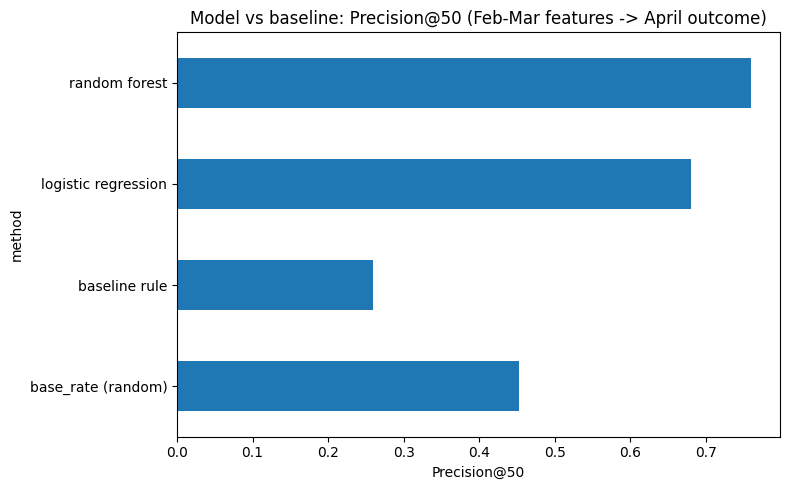

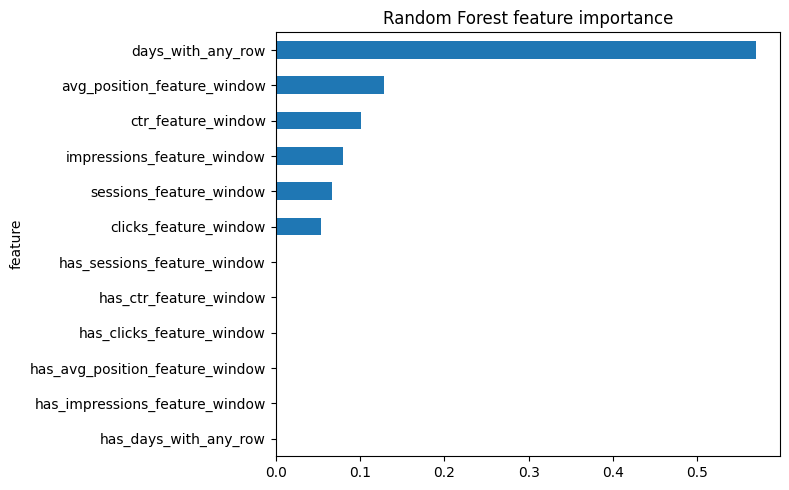

Exported:
 - work/outputs/capstone_metrics.json
 - work/outputs/capstone_ranked_queue.csv
 - work/figures/capstone_model_vs_baseline.png
 - work/figures/capstone_feature_importance.png


In [20]:
import json
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

ranked_queue.to_csv("work/outputs/capstone_ranked_queue.csv", index=False)
metrics_snapshot = {
    "date_generated": pd.Timestamp.now().strftime("%Y-%m-%d"),
    "feature_window": "2026-02-01 to 2026-03-31",
    "target_window": "2026-04-01 to 2026-04-30",
    "n_labeled_pages": int(len(model_df)),
    "n_train_clients": int(train_df["client_hash_id"].nunique()),
    "n_test_clients": int(test_df["client_hash_id"].nunique()),
    "initial_base_rate": round(float(base_rate_test), 3),
    "initial_baseline_precision_at_50": round(float(baseline_p50), 3),
    "initial_logreg_precision_at_50": round(float(logreg_p50), 3),
    "initial_rf_precision_at_50": round(float(rf_p50), 3),
    "leaky_stress_test_precision_at_50": round(float(p50_leaky), 3),
    "label_fix_base_rate": round(float(base_rate_test_v2), 3),
    "label_fix_logreg_precision_at_50": round(float(logreg_p50_v2), 3),
    "label_fix_rf_precision_at_50": round(float(rf_p50_v2), 3),
    "may_holdout_base_rate": round(float(y_holdout.mean()), 3),
    "may_holdout_logreg_precision_at_50": round(float(precision_at_k(y_holdout, logreg_scores_holdout, k=50)), 3),
    "may_holdout_rf_precision_at_50": round(float(precision_at_k(y_holdout, rf_scores_holdout, k=50)), 3),
    "action_mix": test_df["suggested_action"].value_counts(normalize=True).round(3).to_dict(),
}
with open("work/outputs/capstone_metrics.json", "w") as f:
    json.dump(metrics_snapshot, f, indent=2, default=str)
print("Updated metrics_snapshot saved.")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))
results.set_index("method")["precision@50"].plot(kind="barh", ax=ax)
ax.set_xlabel("Precision@50")
ax.set_title("Model vs baseline: Precision@50 (Feb-Mar features -> April outcome)")
plt.tight_layout()
plt.savefig("work/figures/capstone_model_vs_baseline.png", dpi=150)
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 5))
imp_df.sort_values("importance").plot(kind="barh", x="feature", y="importance", ax=ax2, legend=False)
ax2.set_title("Random Forest feature importance")
plt.tight_layout()
plt.savefig("work/figures/capstone_feature_importance.png", dpi=150)
plt.show()

print("Exported:")
for f in os.listdir("work/outputs"):
    print(" - work/outputs/" + f)
for f in os.listdir("work/figures"):
    print(" - work/figures/" + f)

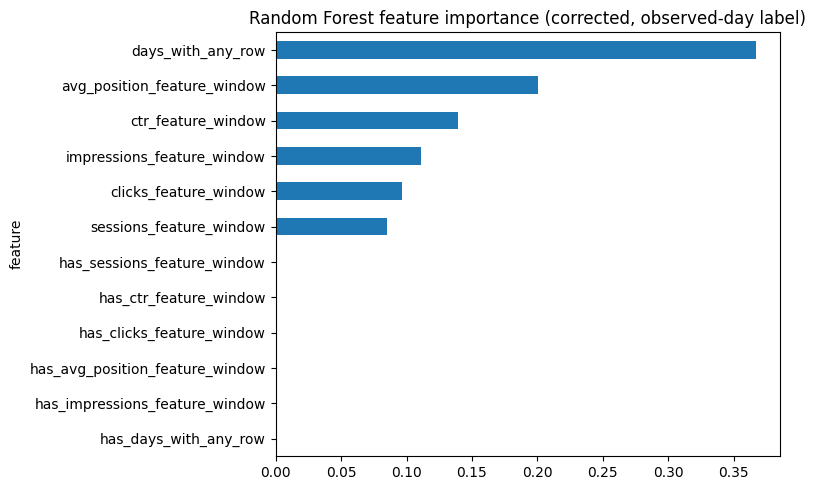

In [21]:
fig3, ax3 = plt.subplots(figsize=(8, 5))
imp_df_v2.sort_values("importance").plot(kind="barh", x="feature", y="importance", ax=ax3, legend=False)
ax3.set_title("Random Forest feature importance (corrected, observed-day label)")
plt.tight_layout()
plt.savefig("work/figures/capstone_feature_importance_v2.png", dpi=150)
plt.show()

## Check if MAY DATA Exists:

In [22]:
try:
    n_may = con.sql(f"""
        SELECT COUNT(*) AS n
        FROM read_parquet('{rel}/fact_content_daily_performance/month=2026-05/data_0.parquet')
    """).df()["n"][0]
    print(f"May 2026: {n_may:,} rows — data exists.")
except Exception as e:
    print("May data not available yet:", e)

May 2026: 11,687,376 rows — data exists.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

5-Minute Demo Outline (Week 8 showcase, optional)

1. Question (30 sec)
   Which pages should a content reviewer prioritize for refresh, given
   a fixed weekly review capacity? A decision problem, not just a model.

2. Method (1 min)
   60 days of real search performance history -> 30 days of genuinely
   future-observed outcome. Random Forest and Logistic Regression,
   client-grouped split, full leakage audit.

3. One chart (1 min)
   Show Fig. 1 (Precision@50: base rate 0.452, baseline rule 0.26,
   Logistic Regression 0.68, Random Forest 0.76 initial).

4. One honest result (1.5 min)
   The 0.76 result was partly a label-design artifact -- caught it,
   fixed it, RF dropped to 0.62. Then tested the fix on a truly unseen
   future month (May): both models scored BELOW random guessing
   (0.40 and 0.34 vs a 0.628 base rate). Diagnosed as real
   non-stationarity in the underlying data, not a broken model.

5. One recommendation (1 min)
   This kind of model needs a retraining/monitoring cadence, not a
   one-time deployment -- validating on one window and assuming it
   holds is the actual risk, and this capstone demonstrates why.

Shareable cuts

Social post (methodology-focused):

Built a model to predict which web pages will lose search visibility
next month, using 79M rows of real production data. It looked strong
(0.76 precision) -- until I audited my own label design, found a flaw,
fixed it, and re-tested on a month the model had never seen. Both
"good" models scored worse than random guessing. The failure was the
real finding: the underlying data shifts month to month, so a
single-snapshot model can't be trusted without ongoing validation.
Sharing the full writeup + honest failure analysis below.

Employer-facing summary (3 sentences):

I built and validated a page-decline prediction model on FlyRank's
79-million-row search performance warehouse, using a genuinely
future-observed label rather than a same-window proxy. After
self-auditing an initial strong result and finding it was partly a
label-design artifact, I corrected it and stress-tested the fix
against an unseen future month, which the model failed -- and I
diagnosed why, tracing it to real non-stationarity in the data. The
result is a rigorously validated, honestly-reported ML pipeline with
a working action-recommendation system, not just a leaderboard score.